# Projekt Dyplomowy 2026

**Autor:** Paweł Myszka 331720

**Temat:** Wyznaczanie poziomów Fibonacciego pod kątem możliwego zastosowania w modelach klasyfikacyjnych (lasy losowe).

# 1. Wczytanie potrzebnych bibliotek

In [44]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import numpy as np
from scipy.signal import argrelextrema
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 2. Pobranie danych giełodwych i uporządkowanie data frame.

In [70]:
#tickers  = ["AAPL", "MSFT", "GOOGL", "AMZN", "SPY", "QQQ", "TSLA", "META"]
# rozszerzone ~30-40 tickerów
tickers = [
    # big tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NVDA", "AMD",
    # indeksy
    "SPY", "QQQ", "DIA", "IWM", "^GSPC", "^IXIC",
    # finanse
    "JPM", "BAC", "GS", "V", "MA",
    # inne sektory
    "JNJ", "PFE", "XOM", "CVX", "WMT", "COST",
    # crypto ETF
    "BITO", "GBTC",
    # europejskie
    "ASML", "SAP", "NVO",
]
okres    = "10y"
interwal = "1d"

dane_tickerow = {}  # słownik: ticker -> df

for ticker in tickers:
    df = yf.download(ticker, period=okres, interval=interwal, progress=False)
    df.columns = df.columns.get_level_values(0)
    df = df.reset_index()
    df.columns.name = None
    dane_tickerow[ticker] = df
    print(f"{ticker}: {len(df)} rekordów  ({df['Date'].min().date()} — {df['Date'].max().date()})")

AAPL: 2514 rekordów  (2016-04-01 — 2026-03-31)
MSFT: 2514 rekordów  (2016-04-01 — 2026-03-31)
GOOGL: 2514 rekordów  (2016-04-01 — 2026-03-31)
AMZN: 2514 rekordów  (2016-04-01 — 2026-03-31)
META: 2514 rekordów  (2016-04-01 — 2026-03-31)
TSLA: 2514 rekordów  (2016-04-01 — 2026-03-31)
NVDA: 2514 rekordów  (2016-04-01 — 2026-03-31)
AMD: 2514 rekordów  (2016-04-01 — 2026-03-31)
SPY: 2514 rekordów  (2016-04-01 — 2026-03-31)
QQQ: 2514 rekordów  (2016-04-01 — 2026-03-31)
DIA: 2514 rekordów  (2016-04-01 — 2026-03-31)
IWM: 2514 rekordów  (2016-04-01 — 2026-03-31)
^GSPC: 2514 rekordów  (2016-04-01 — 2026-03-31)
^IXIC: 2514 rekordów  (2016-04-01 — 2026-03-31)
JPM: 2514 rekordów  (2016-04-01 — 2026-03-31)
BAC: 2514 rekordów  (2016-04-01 — 2026-03-31)
GS: 2514 rekordów  (2016-04-01 — 2026-03-31)
V: 2514 rekordów  (2016-04-01 — 2026-03-31)
MA: 2514 rekordów  (2016-04-01 — 2026-03-31)
JNJ: 2514 rekordów  (2016-04-01 — 2026-03-31)
PFE: 2514 rekordów  (2016-04-01 — 2026-03-31)
XOM: 2514 rekordów  (2016-

**Przetwarzanie data frame:**

1 Usunięcie podowojnych nagłówków (yfinance zwraca wielopoziomowe kolumny, gydbyśmy chcieli pobrać więcej niż jeden indeks).

2 Ustawienie date jako kolumny a nie jako indeks

3 Price ustawia się jako id- usuwamy to aby tabela wyglądała czysto

**Opis pobranych danych:**

Open- cena otwarcia świecy

High — najwyższa cena w ciągu dnia

Low — najniższa cena w ciągu dnia

Close — cena zamknięcia świecy (na końcu dnia)

Volume — wolumen, czyli ile BTC zostało sprzedane w ciągu dnia

**Wstępne wiadomości o pobranych danych**

In [71]:
for ticker, df in dane_tickerow.items():
    print(f"\n{'='*40}")
    print(f"Ticker: {ticker}")
    print(f"Liczba rekordów: {len(df)}")
    print(f"Zakres dat: {df['Date'].min().date()} — {df['Date'].max().date()}")
    print(f"\nBrakujące wartości:")
    print(df.isnull().sum())
    print(f"\nTypy danych:")
    print(df.dtypes)


Ticker: AAPL
Liczba rekordów: 2514
Zakres dat: 2016-04-01 — 2026-03-31

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object

Ticker: MSFT
Liczba rekordów: 2514
Zakres dat: 2016-04-01 — 2026-03-31

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
dtype: object

Ticker: GOOGL
Liczba rekordów: 2514
Zakres dat: 2016-04-01 — 2026-03-31

Brakujące wartości:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Typy danych:
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open       

# Wizualizacja wykresu

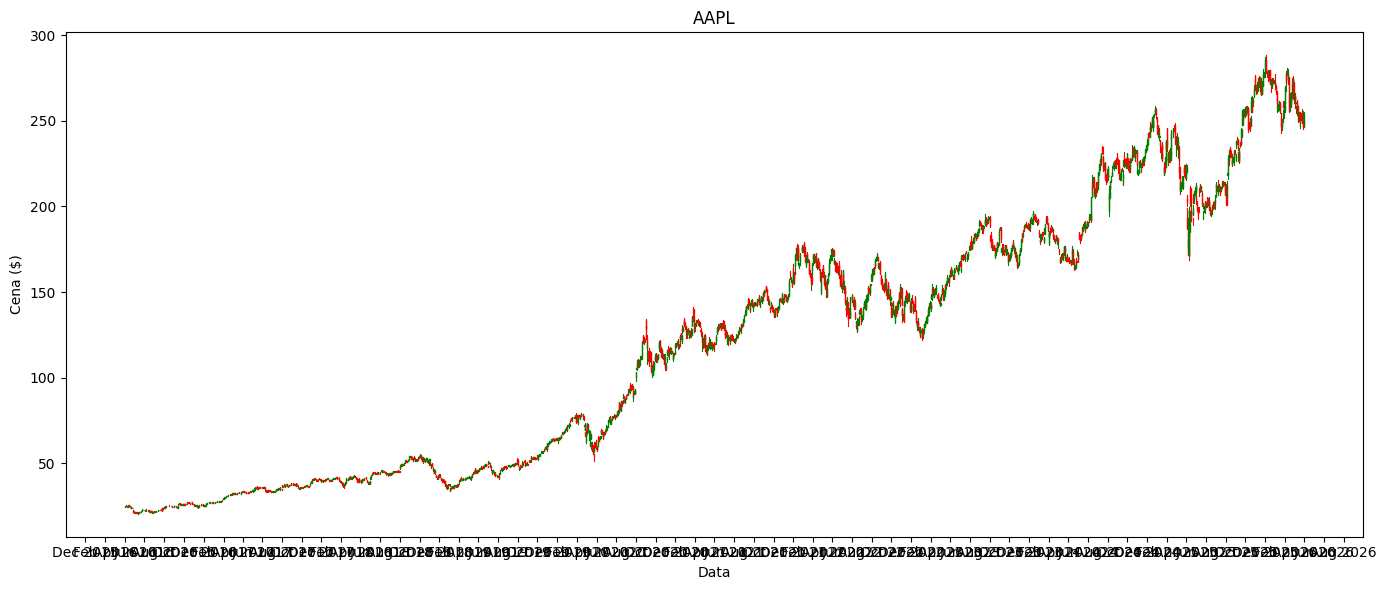

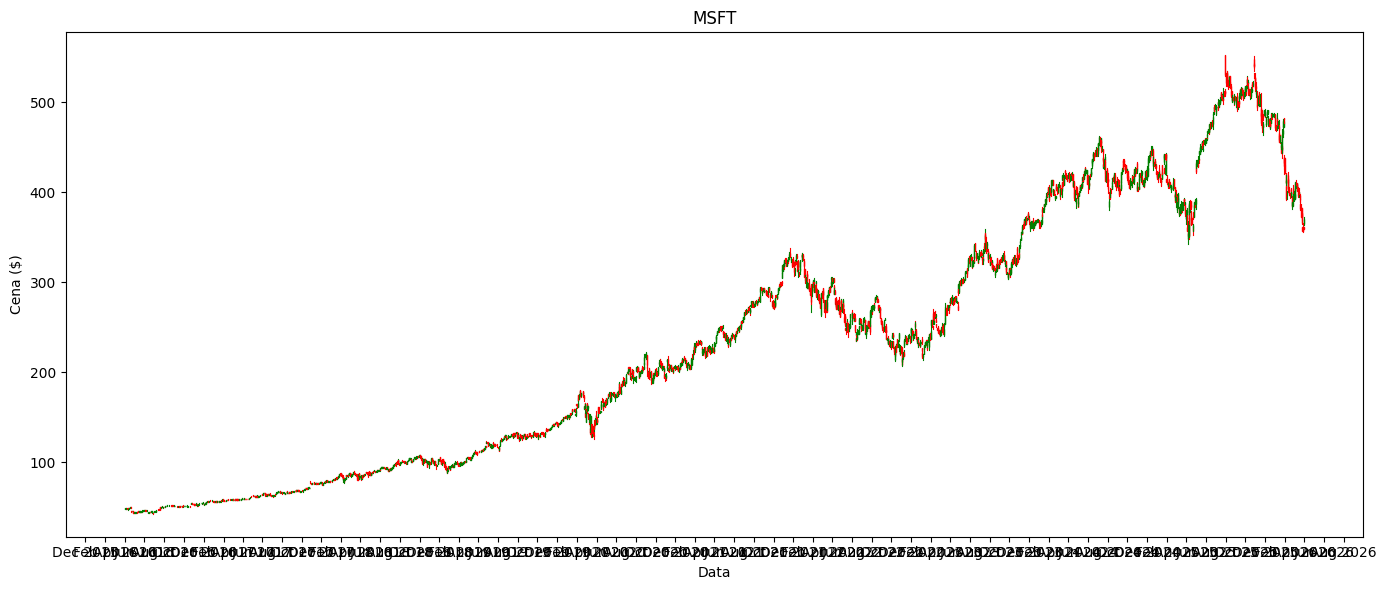

In [72]:
def rysuj_wykres(df, ticker):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

rysuj_wykres(dane_tickerow["AAPL"], "AAPL")
rysuj_wykres(dane_tickerow["MSFT"], "MSFT")

# Sprawdzenie lokalnych punktów min/max

In [73]:
def wykryj_swing_points(df, n=5):
    df = df.copy()
    df["swing_high"] = np.nan
    df["swing_low"]  = np.nan

    idx_high = argrelextrema(df["High"].values, np.greater_equal, order=n)[0]
    idx_low  = argrelextrema(df["Low"].values,  np.less_equal,    order=n)[0]

    df.loc[idx_high, "swing_high"] = df["High"].iloc[idx_high].values
    df.loc[idx_low,  "swing_low"]  = df["Low"].iloc[idx_low].values

    return df

# wywołanie dla każdego tickera
for ticker in tickers:
    dane_tickerow[ticker] = wykryj_swing_points(dane_tickerow[ticker])
    df = dane_tickerow[ticker]
    print(f"{ticker}: Swing high: {df['swing_high'].notna().sum()}  |  Swing low: {df['swing_low'].notna().sum()}")

AAPL: Swing high: 139  |  Swing low: 137
MSFT: Swing high: 152  |  Swing low: 150
GOOGL: Swing high: 160  |  Swing low: 161
AMZN: Swing high: 150  |  Swing low: 154
META: Swing high: 147  |  Swing low: 151
TSLA: Swing high: 151  |  Swing low: 153
NVDA: Swing high: 147  |  Swing low: 148
AMD: Swing high: 150  |  Swing low: 165
SPY: Swing high: 137  |  Swing low: 147
QQQ: Swing high: 142  |  Swing low: 152
DIA: Swing high: 144  |  Swing low: 141
IWM: Swing high: 152  |  Swing low: 144
^GSPC: Swing high: 139  |  Swing low: 148
^IXIC: Swing high: 135  |  Swing low: 153
JPM: Swing high: 135  |  Swing low: 149
BAC: Swing high: 139  |  Swing low: 141
GS: Swing high: 143  |  Swing low: 146
V: Swing high: 145  |  Swing low: 162
MA: Swing high: 154  |  Swing low: 148
JNJ: Swing high: 143  |  Swing low: 148
PFE: Swing high: 150  |  Swing low: 154
XOM: Swing high: 137  |  Swing low: 150
CVX: Swing high: 147  |  Swing low: 158
WMT: Swing high: 148  |  Swing low: 150
COST: Swing high: 152  |  Swing 

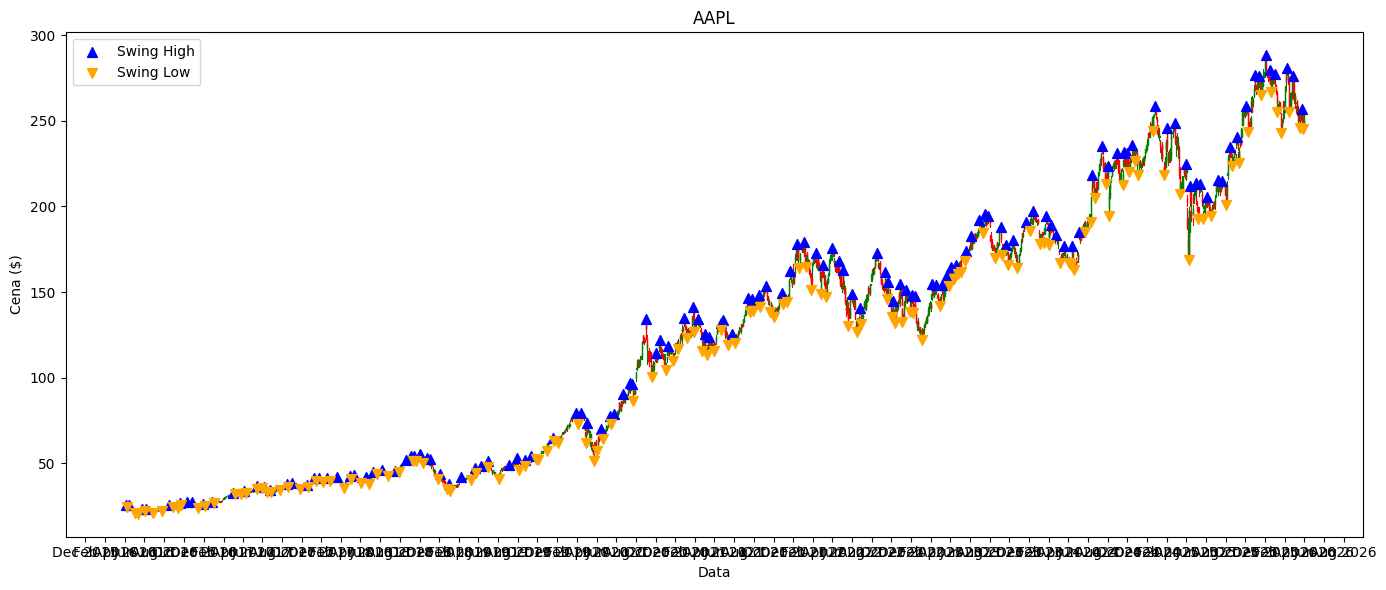

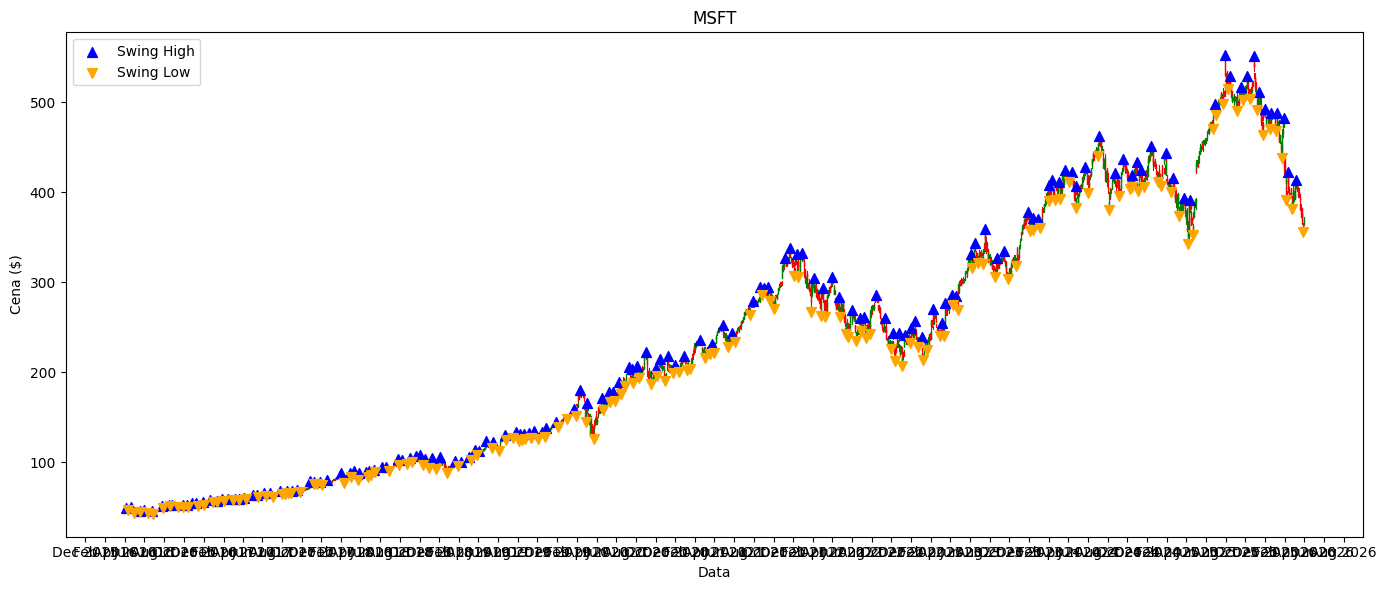

In [74]:
def rysuj_wykres_swing(df, ticker):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
    ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

# wywołanie dla dowolnego tickera
rysuj_wykres_swing(dane_tickerow["AAPL"], "AAPL")
rysuj_wykres_swing(dane_tickerow["MSFT"], "MSFT")

# Wyznaczenie lini trendów

In [75]:
def wyznacz_trendy(df):
    swing_points = []

    for _, row in df.iterrows():
        if not np.isnan(row["swing_high"]):
            swing_points.append((row["Date"], row["swing_high"], "high"))
        if not np.isnan(row["swing_low"]):
            swing_points.append((row["Date"], row["swing_low"], "low"))

    swing_points.sort(key=lambda x: x[0])

    trends = []
    for i in range(len(swing_points) - 1):
        a, b = swing_points[i], swing_points[i + 1]
        if a[2] == "low" and b[2] == "high":
            trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "wzrost"})
        elif a[2] == "high" and b[2] == "low":
            trends.append({"start_date": a[0], "start_price": a[1], "end_date": b[0], "end_price": b[1], "typ": "spadek"})

    return trends

# wywołanie dla każdego tickera
trendy_tickerow = {}  # słownik: ticker -> lista trendów

for ticker in tickers:
    trendy_tickerow[ticker] = wyznacz_trendy(dane_tickerow[ticker])
    print(f"{ticker}: {len(trendy_tickerow[ticker])} trendów")

AAPL: 229 trendów
MSFT: 257 trendów
GOOGL: 274 trendów
AMZN: 254 trendów
META: 249 trendów
TSLA: 234 trendów
NVDA: 243 trendów
AMD: 251 trendów
SPY: 235 trendów
QQQ: 260 trendów
DIA: 237 trendów
IWM: 247 trendów
^GSPC: 239 trendów
^IXIC: 244 trendów
JPM: 229 trendów
BAC: 238 trendów
GS: 247 trendów
V: 256 trendów
MA: 255 trendów
JNJ: 237 trendów
PFE: 261 trendów
XOM: 243 trendów
CVX: 240 trendów
WMT: 240 trendów
COST: 248 trendów
BITO: 125 trendów
GBTC: 260 trendów
ASML: 259 trendów
SAP: 253 trendów
NVO: 257 trendów


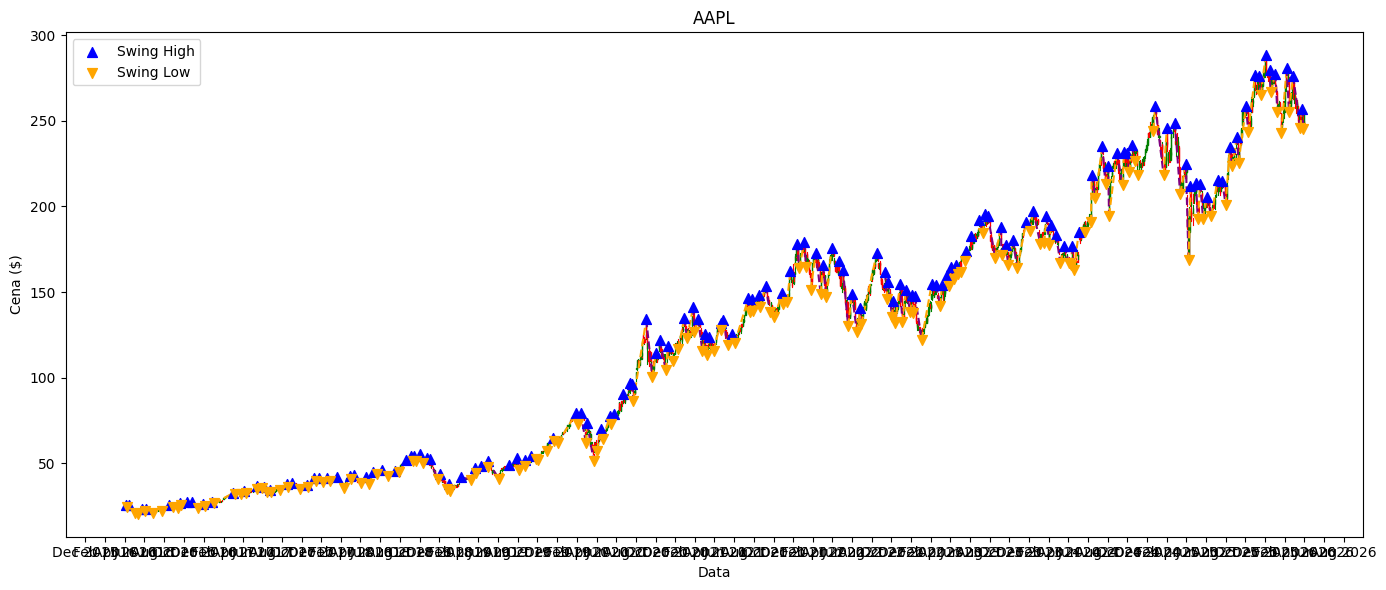

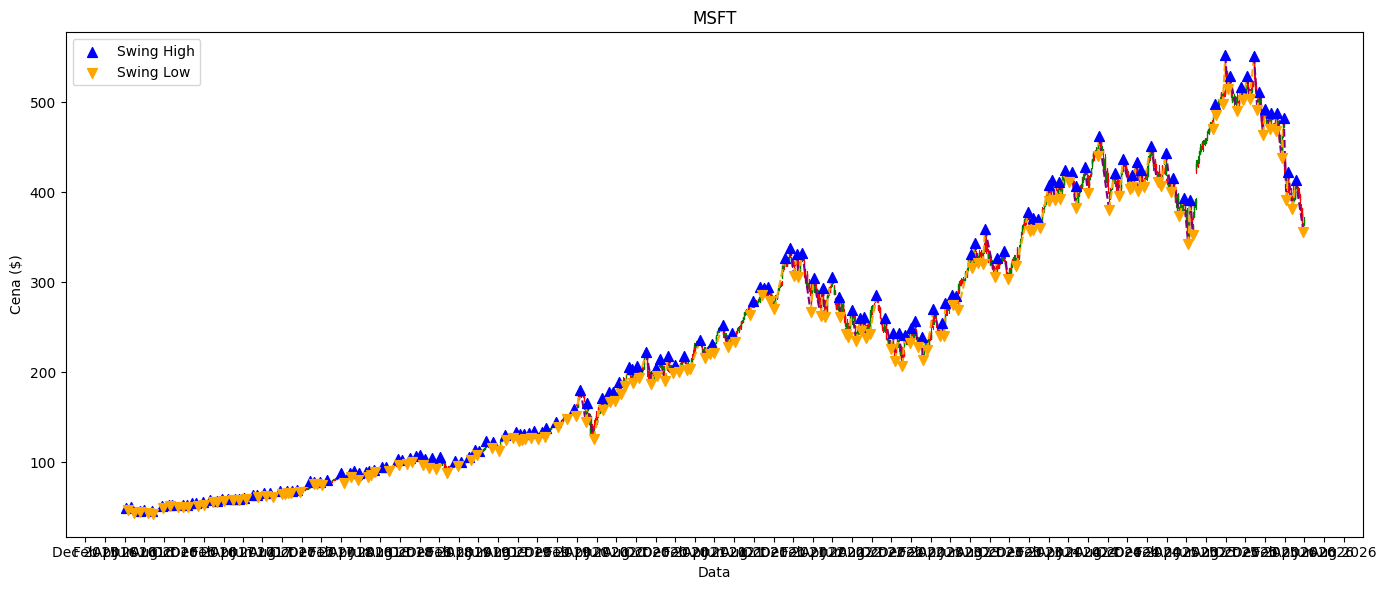

In [76]:
def rysuj_wykres_trendy(df, ticker, trends):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
    ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")

    for t in trends:
        color = "orange" if t["typ"] == "wzrost" else "purple"
        ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]],
                color=color, linewidth=1.5, linestyle="--")

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

# wywołanie dla dowolnego tickera
rysuj_wykres_trendy(dane_tickerow["AAPL"], "AAPL", trendy_tickerow["AAPL"])
rysuj_wykres_trendy(dane_tickerow["MSFT"], "MSFT", trendy_tickerow["MSFT"])

# Wyznaczanie poziomów fibonnaciego

In [77]:
LEVELS = [0, 0.38, 0.5, 0.61, 0.707, 0.878, 1, 1.272, 1.618, 2.058, 2.618, 0.8, 0.236, 0.44, 0.577, 0.667, 0.786, 0.941, 1.13, 1.414, 1.732, 2.236, 0.278, 0.77]
#LEVELS = [0.236, 0.382, 0.5, 0.618, 0.786]

def wyznacz_strefy_fib(trends):
    fib_zones = []

    for t in trends:
        high = t["end_price"]   if t["typ"] == "wzrost" else t["start_price"]
        low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]

        for level in LEVELS:
            price = high - (high - low) * level
            fib_zones.append({
                "start_date": t["start_date"],
                "end_date":   t["end_date"],
                "level":      level,
                "price":      price,
                "typ":        t["typ"]
            })

    return fib_zones

# wywołanie dla każdego tickera
strefy_tickerow = {}

for ticker in tickers:
    strefy_tickerow[ticker] = wyznacz_strefy_fib(trendy_tickerow[ticker])
    print(f"{ticker}: {len(strefy_tickerow[ticker])} stref")

AAPL: 5496 stref
MSFT: 6168 stref
GOOGL: 6576 stref
AMZN: 6096 stref
META: 5976 stref
TSLA: 5616 stref
NVDA: 5832 stref
AMD: 6024 stref
SPY: 5640 stref
QQQ: 6240 stref
DIA: 5688 stref
IWM: 5928 stref
^GSPC: 5736 stref
^IXIC: 5856 stref
JPM: 5496 stref
BAC: 5712 stref
GS: 5928 stref
V: 6144 stref
MA: 6120 stref
JNJ: 5688 stref
PFE: 6264 stref
XOM: 5832 stref
CVX: 5760 stref
WMT: 5760 stref
COST: 5952 stref
BITO: 3000 stref
GBTC: 6240 stref
ASML: 6216 stref
SAP: 6072 stref
NVO: 6168 stref


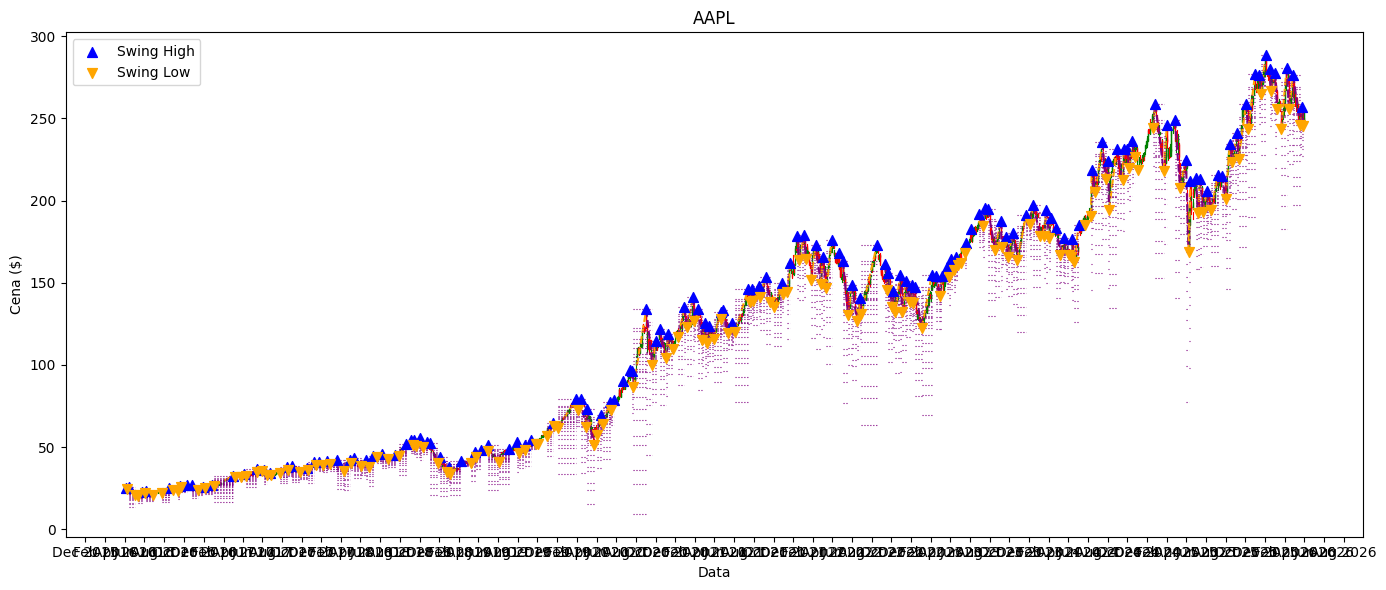

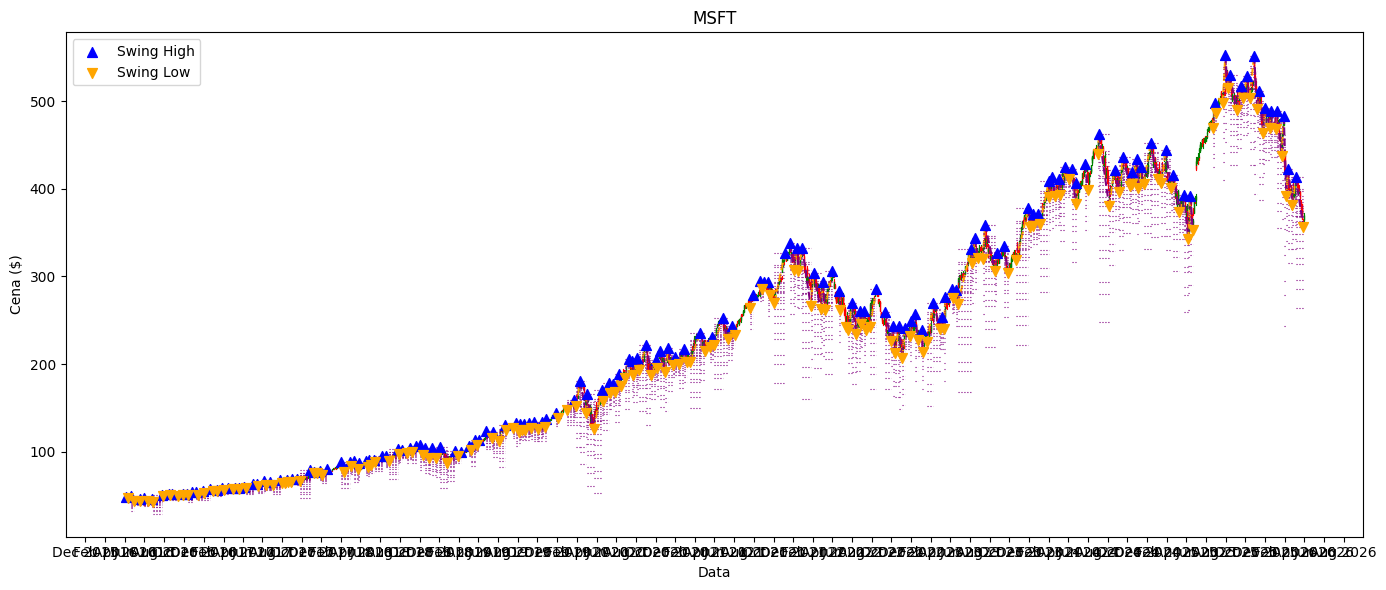

In [78]:
def rysuj_wykres_fib(df, ticker, trends, fib_zones):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
    ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")

    for t in trends:
        color = "orange" if t["typ"] == "wzrost" else "purple"
        ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]],
                color=color, linewidth=1.5, linestyle="--")

    for z in fib_zones:
        ax.hlines(z["price"], z["start_date"], z["end_date"],
                  colors="purple", linewidth=0.8, linestyle=":")

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

# wywołanie dla dowolnego tickera
rysuj_wykres_fib(dane_tickerow["AAPL"], "AAPL", trendy_tickerow["AAPL"], strefy_tickerow["AAPL"])
rysuj_wykres_fib(dane_tickerow["MSFT"], "MSFT", trendy_tickerow["MSFT"], strefy_tickerow["MSFT"])

# Agregacja stref

In [79]:
N_TRENDOW = 3
N_SWIEC   = 20
TOLERANCE = 0.02

def agreguj_strefy(poziomy_z_levelami, tolerance):
    """
    poziomy_z_levelami: lista krotek (cena, level)
    Zwraca: lista krotek (srednia_cena, dominujacy_level)
    """
    if not poziomy_z_levelami:  # zabezpieczenie przed pustą listą
        return []
    
    poziomy_z_levelami = sorted(poziomy_z_levelami, key=lambda x: x[0])
    grupy  = []
    grupa  = [poziomy_z_levelami[0]]

    for p in poziomy_z_levelami[1:]:
        if (p[0] - grupa[-1][0]) / grupa[-1][0] < tolerance:
            grupa.append(p)
        else:
            dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
            grupy.append((np.mean([x[0] for x in grupa]), dom_level))
            grupa = [p]

    dom_level = Counter([x[1] for x in grupa]).most_common(1)[0][0]
    grupy.append((np.mean([x[0] for x in grupa]), dom_level))
    return grupy


def wyznacz_strefy_agregowane(df, trends, n_trendow=N_TRENDOW, n_swiec=N_SWIEC, tolerance=TOLERANCE):
    fib_zones_new = []

    for i in range(n_trendow, len(trends)):
        ostatnie_trendy = trends[i - n_trendow:i]

        poziomy = []
        for t in ostatnie_trendy:
            high = t["end_price"]   if t["typ"] == "wzrost" else t["start_price"]
            low  = t["start_price"] if t["typ"] == "wzrost" else t["end_price"]
            for level in LEVELS:
                poziomy.append((high - (high - low) * level, level))

        grupy = agreguj_strefy(poziomy, tolerance)

        end_date = trends[i]["end_date"]
        future   = df[df["Date"] > end_date]["Date"]
        line_end = future.iloc[n_swiec - 1] if len(future) >= n_swiec else df["Date"].iloc[-1]

        for cena, level in grupy:
            fib_zones_new.append({
                "price":       cena,
                "level":       level,
                "start":       end_date,
                "end":         line_end,
                "typ":         trends[i]["typ"],
                "trend_idx":   i,
                "trend_start": trends[i]["start_date"],
                "trend_end":   trends[i]["end_date"],
            })

    return fib_zones_new


# wywołanie dla każdego tickera
strefy_agg_tickerow = {}

for ticker in tickers:
    strefy_agg_tickerow[ticker] = wyznacz_strefy_agregowane(
        dane_tickerow[ticker],
        trendy_tickerow[ticker]
    )
    print(f"{ticker}: {len(strefy_agg_tickerow[ticker])} stref zagregowanych")

AAPL: 1319 stref zagregowanych
MSFT: 1134 stref zagregowanych
GOOGL: 1312 stref zagregowanych
AMZN: 1534 stref zagregowanych
META: 1759 stref zagregowanych
TSLA: 2740 stref zagregowanych
NVDA: 2358 stref zagregowanych
AMD: 2741 stref zagregowanych
SPY: 626 stref zagregowanych
QQQ: 913 stref zagregowanych
DIA: 631 stref zagregowanych
IWM: 982 stref zagregowanych
^GSPC: 628 stref zagregowanych
^IXIC: 837 stref zagregowanych
JPM: 1120 stref zagregowanych
BAC: 1378 stref zagregowanych
GS: 1375 stref zagregowanych
V: 939 stref zagregowanych
MA: 1110 stref zagregowanych
JNJ: 791 stref zagregowanych
PFE: 1145 stref zagregowanych
XOM: 1221 stref zagregowanych
CVX: 1003 stref zagregowanych
WMT: 889 stref zagregowanych
COST: 957 stref zagregowanych
BITO: 1263 stref zagregowanych
GBTC: 4014 stref zagregowanych
ASML: 1658 stref zagregowanych
SAP: 1136 stref zagregowanych
NVO: 1420 stref zagregowanych


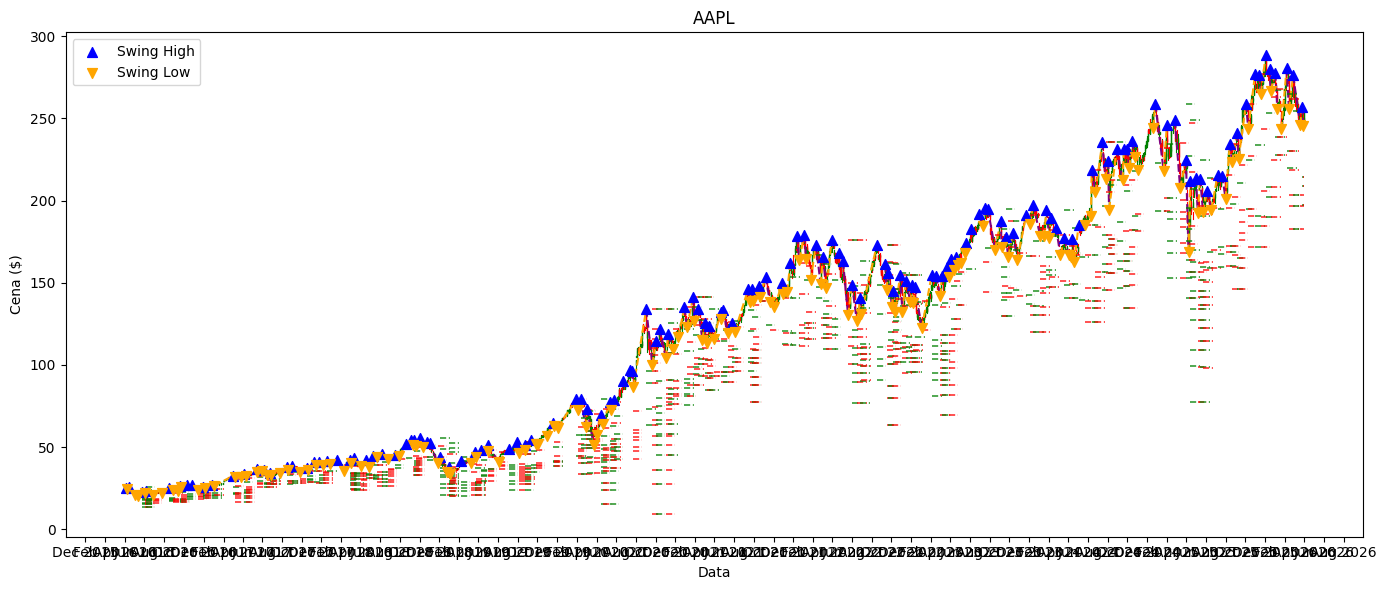

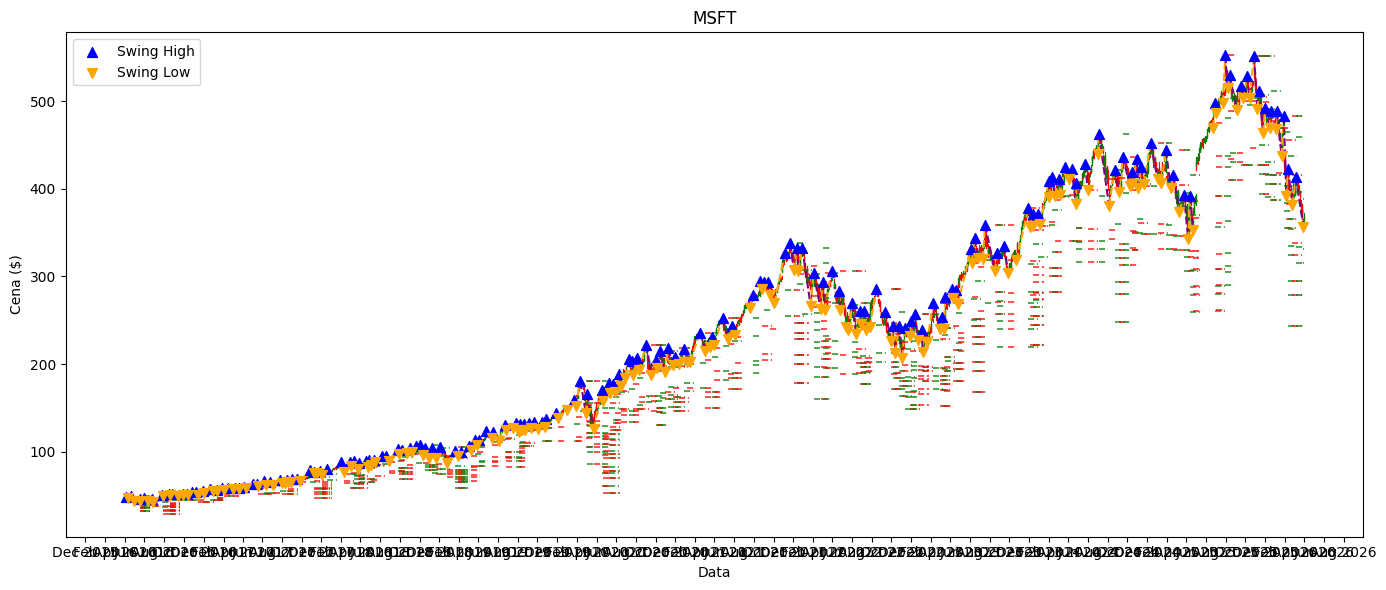

In [80]:
def rysuj_wykres_strefy_agg(df, ticker, trends, fib_zones_new):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
    ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")

    for t in trends:
        color = "orange" if t["typ"] == "wzrost" else "purple"
        ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]],
                color=color, linewidth=1.5, linestyle="--")

    for z in fib_zones_new:
        kolor = "green" if z["typ"] == "wzrost" else "red"
        ax.hlines(z["price"], z["start"], z["end"],
                  colors=kolor, linewidth=1.2, linestyle="--", alpha=0.8)

    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

# wywołanie dla dowolnego tickera
rysuj_wykres_strefy_agg(dane_tickerow["AAPL"], "AAPL", trendy_tickerow["AAPL"], strefy_agg_tickerow["AAPL"])
rysuj_wykres_strefy_agg(dane_tickerow["MSFT"], "MSFT", trendy_tickerow["MSFT"], strefy_agg_tickerow["MSFT"])

# Etykietowanie stref

In [81]:
TOLERANCJA_ODBICIA = 0.02
MIN_ODBICIE        = 0.03
N_SWIEC_ODBICIE    = 5

def etykietuj_strefy(fib_zones_new, df,
                     tolerancja_odbicia=TOLERANCJA_ODBICIA,
                     min_odbicie=MIN_ODBICIE,
                     n_swiec_odbicie=N_SWIEC_ODBICIE):

    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])].copy()

        trafiona     = False
        data_odbicia = None

        for _, s in swiece.iterrows():
            # Krok 1: czy cena dotknęła strefy przez Low, High lub Close
            dotknięcie = (
                abs(s["Close"] - z["price"]) / z["price"] < tolerancja_odbicia or
                abs(s["Low"]   - z["price"]) / z["price"] < tolerancja_odbicia or
                abs(s["High"]  - z["price"]) / z["price"] < tolerancja_odbicia or
                (s["Low"] <= z["price"] <= s["High"])  # strefa wewnątrz świecy
            )

            if dotknięcie:
                # Krok 2: sprawdź kolejne N świec czy nastąpiło odbicie
                swiece_po = df[df["Date"] > s["Date"]].iloc[:n_swiec_odbicie]

                if len(swiece_po) == 0:
                    break

                cena_dotkniecia = s["Close"]

                if z["typ"] == "spadek":
                    # strefa wsparcia – oczekujemy wzrostu po odbiciu
                    max_po = swiece_po["Close"].max()
                    if (max_po - cena_dotkniecia) / cena_dotkniecia >= min_odbicie:
                        trafiona     = True
                        data_odbicia = s["Date"]
                else:
                    # strefa oporu – oczekujemy spadku po odbiciu
                    min_po = swiece_po["Close"].min()
                    if (cena_dotkniecia - min_po) / cena_dotkniecia >= min_odbicie:
                        trafiona     = True
                        data_odbicia = s["Date"]
                break  # sprawdzamy tylko pierwsze dotknięcie

        z["etykieta"]     = "trafiona" if trafiona else "nietrafiona"
        z["data_odbicia"] = data_odbicia

    return fib_zones_new


# wywołanie dla każdego tickera
for ticker in tickers:
    strefy_agg_tickerow[ticker] = etykietuj_strefy(
        strefy_agg_tickerow[ticker],
        dane_tickerow[ticker]
    )
    trafione    = sum(1 for z in strefy_agg_tickerow[ticker] if z["etykieta"] == "trafiona")
    nietrafione = sum(1 for z in strefy_agg_tickerow[ticker] if z["etykieta"] == "nietrafiona")
    print(f"{ticker}: trafione={trafione}  nietrafione={nietrafione}")

AAPL: trafione=80  nietrafione=1239
MSFT: trafione=66  nietrafione=1068
GOOGL: trafione=97  nietrafione=1215
AMZN: trafione=105  nietrafione=1429
META: trafione=148  nietrafione=1611
TSLA: trafione=333  nietrafione=2407
NVDA: trafione=245  nietrafione=2113
AMD: trafione=284  nietrafione=2457
SPY: trafione=32  nietrafione=594
QQQ: trafione=67  nietrafione=846
DIA: trafione=34  nietrafione=597
IWM: trafione=62  nietrafione=920
^GSPC: trafione=29  nietrafione=599
^IXIC: trafione=65  nietrafione=772
JPM: trafione=86  nietrafione=1034
BAC: trafione=111  nietrafione=1267
GS: trafione=110  nietrafione=1265
V: trafione=72  nietrafione=867
MA: trafione=79  nietrafione=1031
JNJ: trafione=34  nietrafione=757
PFE: trafione=75  nietrafione=1070
XOM: trafione=80  nietrafione=1141
CVX: trafione=80  nietrafione=923
WMT: trafione=49  nietrafione=840
COST: trafione=50  nietrafione=907
BITO: trafione=126  nietrafione=1137
GBTC: trafione=579  nietrafione=3435
ASML: trafione=152  nietrafione=1506
SAP: traf

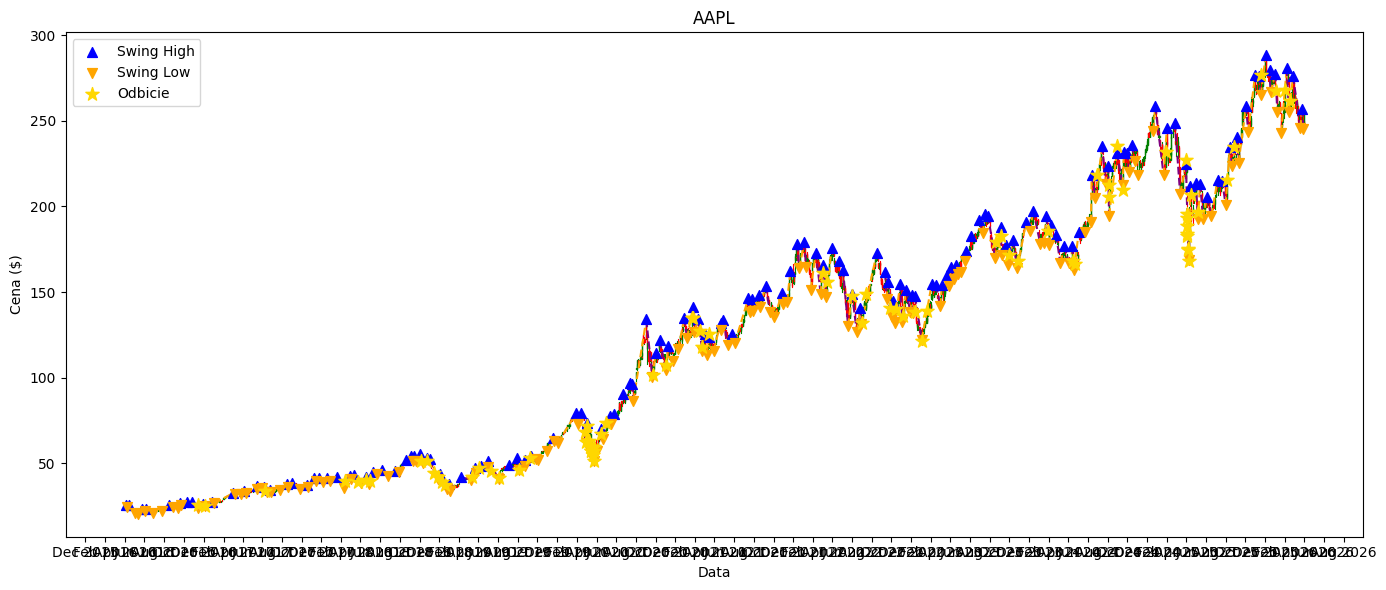

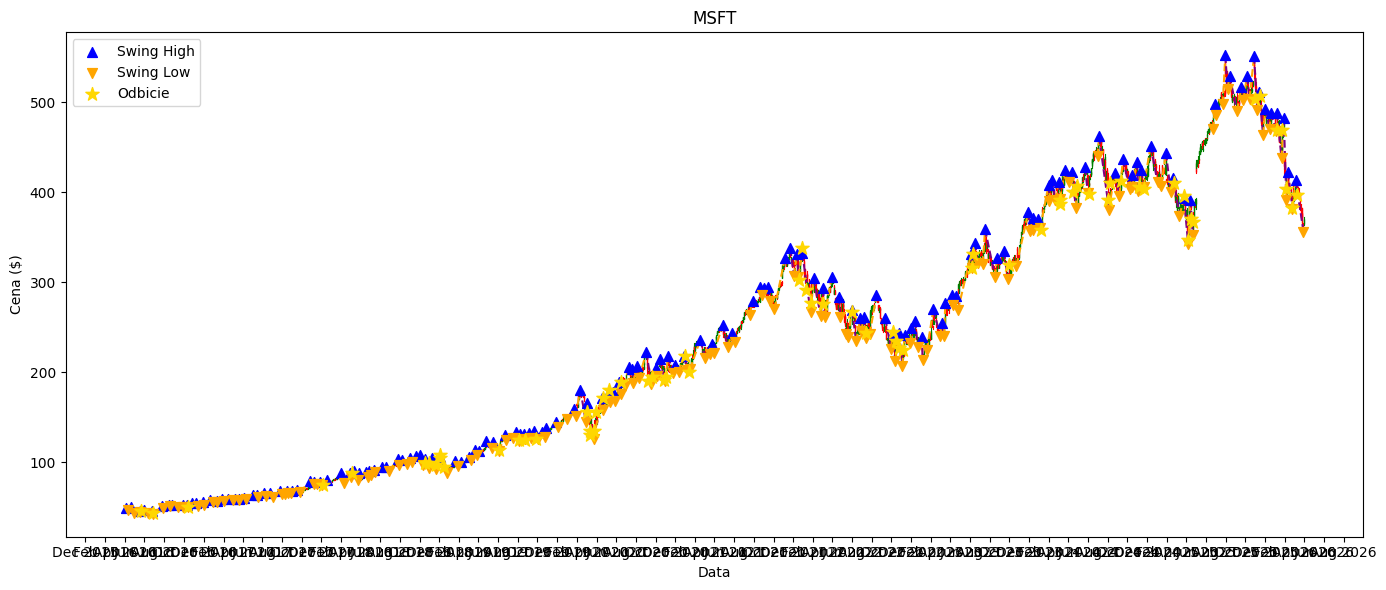

In [82]:
def rysuj_wykres_odbicia(df, ticker, trends, fib_zones_new):
    fig, ax = plt.subplots(figsize=(14, 6))

    for _, row in df.iterrows():
        color = "green" if row["Close"] >= row["Open"] else "red"
        ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8)
        ax.add_patch(Rectangle(
            (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
            0.6,
            abs(row["Close"] - row["Open"]),
            color=color
        ))

    ax.scatter(df["Date"], df["swing_high"], color="blue", marker="^", s=50, zorder=5, label="Swing High")
    ax.scatter(df["Date"], df["swing_low"], color="orange", marker="v", s=50, zorder=5, label="Swing Low")

    for t in trends:
        color = "orange" if t["typ"] == "wzrost" else "purple"
        ax.plot([t["start_date"], t["end_date"]], [t["start_price"], t["end_price"]],
                color=color, linewidth=1.5, linestyle="--")

    for z in fib_zones_new:
        if z["etykieta"] == "trafiona" and z["data_odbicia"] is not None:
            ax.scatter(z["data_odbicia"], z["price"],
                       color="gold", marker="*", s=100, zorder=6, label="Odbicie")

    # usuwa duplikaty z legendy
    handles, labels = ax.get_legend_handles_labels()
    unikalne = dict(zip(labels, handles))
    ax.legend(unikalne.values(), unikalne.keys())

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.title(ticker)
    plt.xlabel("Data")
    plt.ylabel("Cena ($)")
    plt.tight_layout()
    plt.show()

# wywołanie dla dowolnego tickera
rysuj_wykres_odbicia(dane_tickerow["AAPL"], "AAPL", trendy_tickerow["AAPL"], strefy_agg_tickerow["AAPL"])
rysuj_wykres_odbicia(dane_tickerow["MSFT"], "MSFT", trendy_tickerow["MSFT"], strefy_agg_tickerow["MSFT"])

# Generowanie cech dla modelu 

In [ ]:
def generuj_cechy(fib_zones_new, df, trends):
    dane = []

    def oblicz_rsi(series, okres=14):
        delta = series.diff()
        gain = delta.clip(lower=0).rolling(okres).mean()
        loss = (-delta.clip(upper=0)).rolling(okres).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))

    def oblicz_atr(df, okres=14):
        hl = df["High"] - df["Low"]
        hc = (df["High"] - df["Close"].shift()).abs()
        lc = (df["Low"]  - df["Close"].shift()).abs()
        tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        return tr.rolling(okres).mean()

    df = df.copy()
    df["RSI"]   = oblicz_rsi(df["Close"])
    df["ATR"]   = oblicz_atr(df)
    df["SMA20"] = df["Close"].rolling(20).mean()
    df["SMA50"] = df["Close"].rolling(50).mean()

    for z in fib_zones_new:
        swiece = df[(df["Date"] > z["start"]) & (df["Date"] <= z["end"])]
        if len(swiece) == 0:
            continue

        df_przed = df[df["Date"] <= z["start"]]
        if len(df_przed) < 26:  # poprawka: było 25, ale momentum5 wymaga iloc[-6]
            continue
        close_start = df_przed["Close"].iloc[-1]

        trend = next((t for t in trends if t["end_date"] == z["start"]), None)
        if trend is None:
            continue

        df_trend       = df[(df["Date"] >= trend["start_date"]) & (df["Date"] <= trend["end_date"])]
        dlugosc_trendu = len(df_trend)
        zmiana_trendu  = (trend["end_price"] - trend["start_price"]) / trend["start_price"]

        rsi_wejscie = df_przed["RSI"].iloc[-1]
        atr_wejscie = df_przed["ATR"].iloc[-1]
        sma20       = df_przed["SMA20"].iloc[-1]
        sma50       = df_przed["SMA50"].iloc[-1]
        trend_sma   = 1 if sma20 > sma50 else 0
        poziom_fib  = z["level"]

        ilosc_w_klastrze = sum(
            1 for other in fib_zones_new
            if other["trend_idx"] == z["trend_idx"]
            and abs(other["price"] - z["price"]) / z["price"] < 0.02
        )

        vol_ostatnie5    = df_przed["Volume"].iloc[-5:].mean()
        vol_srednia_hist = df_przed["Volume"].iloc[-25:-5].mean()
        vol_relatywny    = vol_ostatnie5 / vol_srednia_hist if vol_srednia_hist > 0 else 1.0

        odleglosc_od_sma20 = (z["price"] - sma20) / sma20 if sma20 > 0 else 0

        atr_sredni_trend = df_trend["ATR"].mean()
        zmiennosc_trendu = atr_sredni_trend / trend["end_price"] if trend["end_price"] > 0 else 0

        momentum5  = (df_przed["Close"].iloc[-1] - df_przed["Close"].iloc[-6]) / df_przed["Close"].iloc[-6]
        rsi_strefa = 1 if rsi_wejscie < 35 else (-1 if rsi_wejscie > 65 else 0)

        dane.append({
            "odleglosc_od_strefy": (close_start - z["price"]) / z["price"],
            "wolumen_sredni":       vol_ostatnie5,
            "wolumen_w_trendzie":   df_trend["Volume"].mean(),
            "dlugosc_trendu":       dlugosc_trendu,
            "zmiana_trendu":        zmiana_trendu,
            "typ_trendu":           1 if z["typ"] == "wzrost" else 0,
            "poziom_fib":           poziom_fib,
            "ilosc_w_klastrze":     ilosc_w_klastrze,
            "vol_relatywny":        vol_relatywny,
            "rsi_wejscie":          rsi_wejscie,
            "atr_wejscie":          atr_wejscie,
            "trend_sma":            trend_sma,
            "odleglosc_od_sma20":   odleglosc_od_sma20,
            "zmiennosc_trendu":     zmiennosc_trendu,
            "momentum5":            momentum5,
            "rsi_strefa":           rsi_strefa,
            "etykieta":             1 if z["etykieta"] == "trafiona" else 0
        })

    return pd.DataFrame(dane)


# wywołanie dla każdego tickera i złączenie w jeden df_model
ramki = []

for ticker in tickers:
    df_ticker = generuj_cechy(
        strefy_agg_tickerow[ticker],
        dane_tickerow[ticker],
        trendy_tickerow[ticker]
    )
    df_ticker["ticker"] = ticker  # zachowujemy info o tickerze do podziału
    ramki.append(df_ticker)

df_model = pd.concat(ramki, ignore_index=True)

print(f"Łączna liczba przykładów: {len(df_model)}")
print(f"\nRozkład etykiet:\n{df_model['etykieta'].value_counts()}")
print(f"\nLiczba cech: {df_model.shape[1] - 2}")  # -2 bo etykieta i ticker
print(f"\nBrakujące wartości:\n{df_model.isnull().sum()}")
print(f"\nPrzykłady per ticker:")
print(df_model.groupby("ticker")["etykieta"].value_counts().unstack(fill_value=0))

# Podział cech

In [ ]:
train_ramki, test_ramki = [], []

for ticker in tickers:
    dane_ticker = df_model[df_model["ticker"] == ticker]
    split = int(len(dane_ticker) * 0.8)
    train_ramki.append(dane_ticker.iloc[:split])
    test_ramki.append(dane_ticker.iloc[split:])

train_df = pd.concat(train_ramki, ignore_index=True)
test_df  = pd.concat(test_ramki,  ignore_index=True)

X_train = train_df.drop(columns=["etykieta", "ticker"])
X_test  = test_df.drop(columns=["etykieta", "ticker"])
y_train = train_df["etykieta"]
y_test  = test_df["etykieta"]

print(f"Treningowy: {len(X_train)} próbek")
print(f"Testowy:    {len(X_test)} próbek")
print(f"\nRozkład etykiet trening:\n{y_train.value_counts()}")
print(f"\nRozkład etykiet test:\n{y_test.value_counts()}")

Treningowy: 9064 próbek
Testowy:    2269 próbek

Rozkład etykiet trening:
etykieta
0    8324
1     740
Name: count, dtype: int64

Rozkład etykiet test:
etykieta
0    2082
1     187
Name: count, dtype: int64


# Trening i ocena modelu

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"Po SMOTE: {Counter(y_train_res)}")

scaler = StandardScaler()
X_train_scaled     = scaler.fit_transform(X_train)
X_test_scaled      = scaler.transform(X_test)
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled_res  = scaler.transform(X_test)

Po SMOTE: Counter({0: 8324, 1: 4162})


In [ ]:
modele = {
    "Random Forest":        (RandomForestClassifier(n_estimators=100, random_state=42,
                                                    class_weight='balanced', min_samples_leaf=5),
                             X_train_res, X_test),
    "Drzewo decyzyjne":     (DecisionTreeClassifier(random_state=42,
                                                    class_weight='balanced'),
                             X_train_res, X_test),
    "SVM":                  (SVC(random_state=42, class_weight='balanced', probability=True),
                             X_train_res_scaled, X_test_scaled_res),
    "Regresja logistyczna": (LogisticRegression(random_state=42, class_weight='balanced'),
                             X_train_res_scaled, X_test_scaled_res),
    "XGBoost":              (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                           subsample=0.8, colsample_bytree=0.8,
                                           random_state=42, eval_metric="logloss"),
                             X_train_res, X_test),
}

for nazwa, (model, X_tr, X_te) in modele.items():
    model.fit(X_tr, y_train_res)
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    print(f"{'='*50}")
    print(f"{nazwa}")
    print(f"  Dokładność : {accuracy_score(y_test, y_pred):.2f}")
    print(f"  F1-score   : {f1_score(y_test, y_pred, zero_division=0):.2f}")
    print(f"  Macierz pomyłek:")
    print(f"    [[TN={cm[0,0]:>4}  FP={cm[0,1]:>4}]")
    print(f"     [FN={cm[1,0]:>4}  TP={cm[1,1]:>4}]]")
    print(classification_report(y_test, y_pred,
                                target_names=["nietrafiona", "trafiona"],
                                zero_division=0))

Random Forest
  Dokładność : 0.88
  F1-score   : 0.46
  Macierz pomyłek:
    [[TN=1886  FP= 196]
     [FN=  74  TP= 113]]
              precision    recall  f1-score   support

 nietrafiona       0.96      0.91      0.93      2082
    trafiona       0.37      0.60      0.46       187

    accuracy                           0.88      2269
   macro avg       0.66      0.76      0.69      2269
weighted avg       0.91      0.88      0.89      2269

Drzewo decyzyjne
  Dokładność : 0.87
  F1-score   : 0.38
  Macierz pomyłek:
    [[TN=1893  FP= 189]
     [FN=  99  TP=  88]]
              precision    recall  f1-score   support

 nietrafiona       0.95      0.91      0.93      2082
    trafiona       0.32      0.47      0.38       187

    accuracy                           0.87      2269
   macro avg       0.63      0.69      0.65      2269
weighted avg       0.90      0.87      0.88      2269

SVM
  Dokładność : 0.81
  F1-score   : 0.37
  Macierz pomyłek:
    [[TN=1711  FP= 371]
     [FN=  6

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import precision_recall_curve

# GridSearch
param_grid = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [5, 10, 20, None],
    "min_samples_leaf": [3, 5, 10],
    "max_features":     ["sqrt", "log2"]
}
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid, cv=tscv, scoring="f1", n_jobs=-1, verbose=1
)
grid.fit(X_train_res, y_train_res)
print(f"Najlepsze parametry: {grid.best_params_}")
print(f"Najlepsze F1 CV:     {grid.best_score_:.2f}")

# ocena finalnego modelu
najlepszy_rf  = grid.best_estimator_
y_proba_final = najlepszy_rf.predict_proba(X_test)[:, 1]

# próg 0.5
y_pred_05 = najlepszy_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_05)
print(f"\nRandom Forest (GridSearch) — próg 0.5")
print(f"  F1-score   : {f1_score(y_test, y_pred_05, zero_division=0):.2f}")
print(f"  Macierz pomyłek:")
print(f"    [[TN={cm[0,0]:>4}  FP={cm[0,1]:>4}]")
print(f"     [FN={cm[1,0]:>4}  TP={cm[1,1]:>4}]]")
print(classification_report(y_test, y_pred_05,
                             target_names=["nietrafiona", "trafiona"], zero_division=0))

# optymalny próg
precisions, recalls, progi = precision_recall_curve(y_test, y_proba_final)
f1_scores     = 2 * precisions * recalls / (precisions + recalls + 1e-9)
najlepszy_prog = progi[f1_scores[:-1].argmax()]
y_pred_prog   = (y_proba_final >= najlepszy_prog).astype(int)
cm2 = confusion_matrix(y_test, y_pred_prog)
print(f"\nRandom Forest (GridSearch) — próg {najlepszy_prog:.2f}")
print(f"  F1-score   : {f1_score(y_test, y_pred_prog, zero_division=0):.2f}")
print(f"  Macierz pomyłek:")
print(f"    [[TN={cm2[0,0]:>4}  FP={cm2[0,1]:>4}]")
print(f"     [FN={cm2[1,0]:>4}  TP={cm2[1,1]:>4}]]")
print(classification_report(y_test, y_pred_prog,
                             target_names=["nietrafiona", "trafiona"], zero_division=0))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Najlepsze parametry: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 300}
Najlepsze F1 CV:     0.66

Random Forest (GridSearch) — próg 0.5
  F1-score   : 0.43
  Macierz pomyłek:
    [[TN=1803  FP= 279]
     [FN=  61  TP= 126]]
              precision    recall  f1-score   support

 nietrafiona       0.97      0.87      0.91      2082
    trafiona       0.31      0.67      0.43       187

    accuracy                           0.85      2269
   macro avg       0.64      0.77      0.67      2269
weighted avg       0.91      0.85      0.87      2269


Random Forest (GridSearch) — próg 0.64
  F1-score   : 0.46
  Macierz pomyłek:
    [[TN=1938  FP= 144]
     [FN=  87  TP= 100]]
              precision    recall  f1-score   support

 nietrafiona       0.96      0.93      0.94      2082
    trafiona       0.41      0.53      0.46       187

    accuracy                           0.90      2269
   m

# Sprawdzenie ważności cech

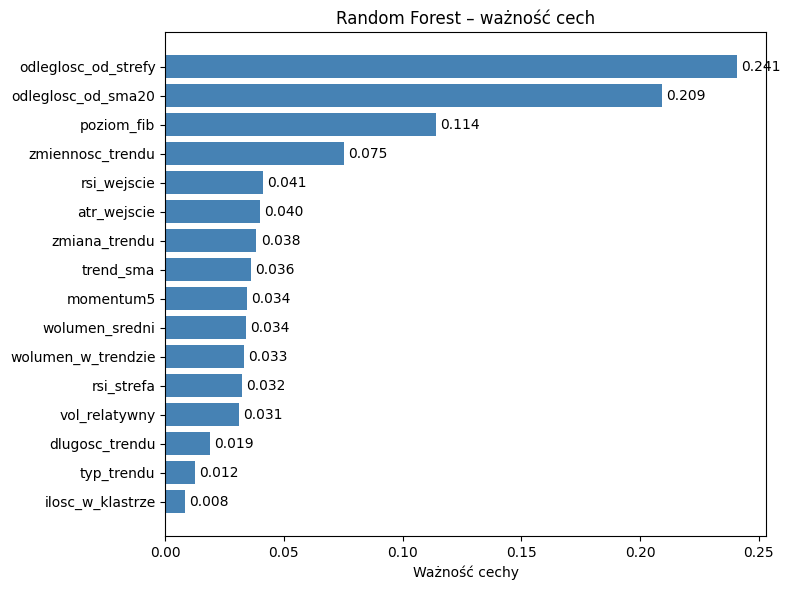

Top 3 najważniejsze cechy:
poziom_fib             0.114053
odleglosc_od_sma20     0.209213
odleglosc_od_strefy    0.240940

Top 3 najmniej ważne cechy (kandydaci do usunięcia):
ilosc_w_klastrze    0.008325
typ_trendu          0.012475
dlugosc_trendu      0.018792


In [ ]:
rf_model    = modele["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_, 
                        index=X_train_res.columns if hasattr(X_train_res, 'columns') 
                        else X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importances.index, importances.values, color="steelblue")
ax.set_xlabel("Ważność cechy")
ax.set_title("Random Forest – ważność cech")
ax.bar_label(bars, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

# bonus — top 3 najważniejszych i najsłabszych cech
print("Top 3 najważniejsze cechy:")
print(importances.tail(3).to_string())
print("\nTop 3 najmniej ważne cechy (kandydaci do usunięcia):")
print(importances.head(3).to_string())

### TO DO


Zwiekszyc F1 score

DOROBIC WROZENIE Z FUSOW JEZELI BEDZIE GIT- przewidywanie przyslzosci jezlei dobrze wytrenujemy model